In [1]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

data="C:/Users/Minfo/OneDrive/Desktop/Nouveau dossier (2)/dataset.csv"
df = pd.read_csv(data, encoding='ISO-8859-1', sep=';')
df.head()


,IP_source,IP_destination,Port_source,Port_destination,Protocole,TTL_moy,Service_cible,Pays_source,Heure_connexion,Durée_flux,...,IAT_flux_moy,Nb_flag_SYN,Nb_flag_ACK,Nb_flag_RST,Ratio_SYN_ACK,Volume_par_paquet_moy,0,Tentatives_connexion,Nb_connexions_simult,Etiquete
0,1.921681e+09,1049775177,509250.0,4430.0,TCP,1280.0,HTTPS,US,19:40:00,1165006300,...,2427096458,20.0,470.0,NaN,417,25808,479,40.0,50.0,1
1,1.921681e+09,192168103,604670.0,530.0,UDP,640.0,DNS,CA,13:26:00,701500,...,"1,74858E+16",0.0,0.0,0.0,0,6914,75,40.0,30.0,0
2,1.921681e+08,192168103,572210.0,530.0,UDP,1280.0,DNS,GB,08:34:00,1620,...,540,0.0,0.0,0.0,0,832,298,10.0,10.0,0
3,1.921681e+08,192168103,558700.0,530.0,UDP,1280.0,DNS,MA,17:35:00,1760,...,5866666667,0.0,0.0,0.0,0,344,25,40.0,30.0,0
4,NaN,192168101,625170.0,530.0,UDP,640.0,DNS,IT,11:07:00,873340,...,873340,0.0,0.0,0.0,#NOM?,510,156,30.0,60.0,0


In [2]:
df.info()
sns.scatterplot(
    x="IAT_flux_moy",
    y="Label",
    hue="Etiquete",
    data=df
)
plt.title("Flow IAT Mean vs Label")
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103000 entries, 0 to 102999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   IP_source              97824 non-null   float64
 1   IP_destination         97941 non-null   object 
 2   Port_source            97979 non-null   float64
 3   Port_destination       97875 non-null   float64
 4   Protocole              94816 non-null   object 
 5   TTL_moy                99875 non-null   float64
 6   Service_cible          94984 non-null   object 
 7   Pays_source            99889 non-null   object 
 8   Heure_connexion        100930 non-null  object 
 9   Durée_flux             97943 non-null   object 
 10  Nb_paquets_envoyés     97921 non-null   float64
 11  Débit_paquets_s        97892 non-null   object 
 12  Débit_octets_s         97825 non-null   object 
 13  IAT_flux_moy           97918 non-null   object 
 14  Nb_flag_SYN            97902 non-nul

ValueError: Could not interpret value `Label` for `y`. An entry with this name does not appear in `data`.

In [6]:
df.isnull().sum()

IP_source                5176
IP_destination           5059
Port_source              5021
Port_destination         5125
Protocole                8184
TTL_moy                  3125
Service_cible            8016
Pays_source              3111
Heure_connexion          2070
Durée_flux               5057
Nb_paquets_envoyés       5079
Débit_paquets_s          5108
Débit_octets_s           5175
IAT_flux_moy             5082
Nb_flag_SYN              5098
Nb_flag_ACK              5078
Nb_flag_RST              5270
Ratio_SYN_ACK            5204
Volume_par_paquet_moy    5143
0                        5027
Tentatives_connexion     5189
Nb_connexions_simult     5185
Etiquete                    0
dtype: int64

In [7]:
df.describe()

,IP_source,Port_source,Port_destination,TTL_moy,Nb_paquets_envoyés,Nb_flag_SYN,Nb_flag_ACK,Nb_flag_RST,Tentatives_connexion,Nb_connexions_simult,Etiquete
count,9.782400e+04,97979.000000,97875.000000,99875.000000,9.792100e+04,97902.000000,9.792200e+04,97730.000000,97811.000000,97815.000000,103000.000000
mean,7.168461e+08,481605.546699,6450.792337,829.724155,1.750558e+02,12.247860,3.525991e+02,7.014223,3367.712425,3773.280070,0.356728
std,8.795332e+08,145111.383781,63255.287920,598.164191,1.214525e+04,11.979498,2.810602e+04,11.367231,5824.239156,5976.229905,0.479036
min,8.601000e+03,-5000.000000,-4980.000000,10.000000,-3.200000e+03,0.000000,0.000000e+00,0.000000,-19860.000000,10.000000,0.000000
25%,1.721601e+06,411610.000000,530.000000,470.000000,2.000000e+01,0.000000,0.000000e+00,0.000000,20.000000,40.000000,0.000000
50%,1.921681e+08,521140.000000,800.000000,640.000000,6.000000e+01,20.000000,1.000000e+02,0.000000,40.000000,80.000000,0.000000
75%,1.921681e+09,587280.000000,800.000000,1280.000000,9.000000e+01,20.000000,1.300000e+02,10.000000,5050.000000,6630.000000,1.000000
max,1.982522e+10,999650.000000,999840.000000,2550.000000,2.003320e+06,130.000000,4.709340e+06,1030.000000,19990.000000,19990.000000,1.000000


In [8]:
          ##### PRETRAITEMENT 

### Analyse et Nettoyage Initial 
# 1. Remplacer les chaînes de caractères d'erreur d'Excel par des vraies valeurs vides (NaN)
df = df.replace('#NOM?', np.nan)

# 2. Vérifier combien de valeurs manquantes (NaN) il y a par colonne
print("--- Nombre de valeurs manquantes par indicateur ---")
print(df.isnull().sum())

# 3. Regarder la répartition entre le trafic normal (0) et les attaques (1)
print("\n--- Répartition des classes (0 = Normal, 1 = Attaque) ---")
print(df['Etiquete'].value_counts())

--- Nombre de valeurs manquantes par indicateur ---
IP_source                5176
IP_destination           5059
Port_source              5021
Port_destination         5125
Protocole                8184
TTL_moy                  3125
Service_cible            8016
Pays_source              3111
Heure_connexion          2070
Durée_flux               5057
Nb_paquets_envoyés       5079
Débit_paquets_s          5108
Débit_octets_s           5175
IAT_flux_moy             5082
Nb_flag_SYN              5098
Nb_flag_ACK              5078
Nb_flag_RST              5270
Ratio_SYN_ACK            5205
Volume_par_paquet_moy    5143
0                        5027
Tentatives_connexion     5189
Nb_connexions_simult     5185
Etiquete                    0
dtype: int64

--- Répartition des classes (0 = Normal, 1 = Attaque) ---
Etiquete
0    66257
1    36743
Name: count, dtype: int64


In [12]:
# 1. Sélection des variables qualitatives réseau à traiter
variables_quali = ['Protocole', 'Service_cible']

# 2. Remplacement des valeurs manquantes (NaN) par la chaîne de caractères 'UNKNOWN'
for col in variables_quali:
    df[col] = df[col].fillna('UNKNOWN')

# 3. Vérification rapide pour s'assurer qu'il ne reste aucune valeur manquante dans ces colonnes
print("--- Vérification du traitement des variables qualitatives ---")
print("Valeurs manquantes restants dans 'Protocole' :", df['Protocole'].isnull().sum())
print("Valeurs manquantes restants dans 'Service_cible' :", df['Service_cible'].isnull().sum())

# 4. Affichage d'un aperçu pour voir le résultat visuellement
print("\n--- Aperçu des premières lignes du dataset après modification ---")
display(df[variables_quali].head())

--- Vérification du traitement des variables qualitatives ---
Valeurs manquantes restants dans 'Protocole' : 0
Valeurs manquantes restants dans 'Service_cible' : 0

--- Aperçu des premières lignes du dataset après modification ---


,Protocole,Service_cible
0,TCP,HTTPS
1,UDP,DNS
2,UDP,DNS
3,UDP,DNS
4,UDP,DNS


In [13]:
import pandas as pd
import numpy as np

# 1. On liste les colonnes qualitatives et la cible à NE PAS toucher
colonnes_exclues = ['IP_source', 'IP_destination', 'Protocole', 'Service_cible', 'Pays_source', 'Heure_connexion', 'Etiquete']

# 2. On identifie automatiquement toutes les autres colonnes (les quantitatives)
colonnes_quantitatives = [col for col in df.columns if col not in colonnes_exclues]

# 3. Boucle de nettoyage : conversion en numérique et imputation par la moyenne
for col in colonnes_quantitatives:
    # On force la conversion en chiffres (les textes bizarres comme #NOM? deviennent des NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # On calcule la moyenne de la colonne concernée
    moyenne_colonne = df[col].mean()
    
    # On remplace les valeurs manquantes (NaN) par cette moyenne
    if pd.notna(moyenne_colonne):
        df[col] = df[col].fillna(moyenne_colonne)
    else:
        df[col] = df[col].fillna(0) # Sécurité si une colonne était totalement vide

# 4. Vérification du résultat
print("--- VÉRIFICATION DES VALEURS MANQUANTES QUANTITATIVES ---")
manquants_quanti = df[colonnes_quantitatives].isnull().sum().sum()
print(f"Nombre de valeurs manquantes restantes dans les colonnes numériques : {manquants_quanti}")

print("\n--- Aperçu des premières lignes pour validation ---")
display(df[colonnes_quantitatives[:4]].head())

--- VÉRIFICATION DES VALEURS MANQUANTES QUANTITATIVES ---
Nombre de valeurs manquantes restantes dans les colonnes numériques : 0

--- Aperçu des premières lignes pour validation ---


,Port_source,Port_destination,TTL_moy,Durée_flux
0,509250.0,4430.0,1280.0,1.165006e+09
1,604670.0,530.0,640.0,7.015000e+05
2,572210.0,530.0,1280.0,1.620000e+03
3,558700.0,530.0,1280.0,1.760000e+03
4,625170.0,530.0,640.0,8.733400e+05


In [14]:
df.isnull().sum()

IP_source                5176
IP_destination           5059
Port_source                 0
Port_destination            0
Protocole                   0
TTL_moy                     0
Service_cible               0
Pays_source              3111
Heure_connexion          2070
Durée_flux                  0
Nb_paquets_envoyés          0
Débit_paquets_s             0
Débit_octets_s              0
IAT_flux_moy                0
Nb_flag_SYN                 0
Nb_flag_ACK                 0
Nb_flag_RST                 0
Ratio_SYN_ACK               0
Volume_par_paquet_moy       0
0                           0
Tentatives_connexion        0
Nb_connexions_simult        0
Etiquete                    0
dtype: int64

In [16]:
df= df.drop(columns=['Pays_source', 'Heure_connexion'], errors='ignore') 
df.isnull().sum()

IP_source                5176
IP_destination           5059
Port_source                 0
Port_destination            0
Protocole                   0
TTL_moy                     0
Service_cible               0
Durée_flux                  0
Nb_paquets_envoyés          0
Débit_paquets_s             0
Débit_octets_s              0
IAT_flux_moy                0
Nb_flag_SYN                 0
Nb_flag_ACK                 0
Nb_flag_RST                 0
Ratio_SYN_ACK               0
Volume_par_paquet_moy       0
0                           0
Tentatives_connexion        0
Nb_connexions_simult        0
Etiquete                    0
dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder

# 1. On crée deux encodeurs distincts (un pour chaque colonne)
encodeur_proto = LabelEncoder()
encodeur_service = LabelEncoder()

# 2. On transforme le texte en chiffres pour la colonne 'Protocole'
df['Protocole'] = encodeur_proto.fit_transform(df['Protocole'].astype(str))

# 3. On transforme le texte en chiffres pour la colonne 'Service_cible'
df['Service_cible'] = encodeur_service.fit_transform(df['Service_cible'].astype(str))

# 4. On vérifie visuellement le résultat sur les 5 premières lignes
print("--- VÉRIFICATION DE L'ENCODAGE ---")
display(df[['Protocole', 'Service_cible']].head())

# === 5. AFFICHAGE DES VRAIES CORRESPONDANCES ===
print("--- VÉRIFICATION DE L'ENCODAGE REPROPRE ---")
display(df[['Protocole', 'Service_cible']].head())

print("\n=== CORRESPONDANCE POUR LES PROTOCOLES ===")
for index, classe in enumerate(encodeur_proto.classes_):
    print(f"Chiffre {index} ➔ Protocole : {classe}")

print("\n=== CORRESPONDANCE POUR LES SERVICES CIBLES ===")
for index, classe in enumerate(encodeur_service.classes_):
    print(f"Chiffre {index} ➔ Service : {classe}")


--- VÉRIFICATION DE L'ENCODAGE ---


,Protocole,Service_cible
0,2,4
1,3,0
2,3,0
3,3,0
4,3,0


--- VÉRIFICATION DE L'ENCODAGE REPROPRE ---


,Protocole,Service_cible
0,2,4
1,3,0
2,3,0
3,3,0
4,3,0



=== CORRESPONDANCE POUR LES PROTOCOLES ===
Chiffre 0 ➔ Protocole : 0
Chiffre 1 ➔ Protocole : 1
Chiffre 2 ➔ Protocole : 2
Chiffre 3 ➔ Protocole : 3
Chiffre 4 ➔ Protocole : 4

=== CORRESPONDANCE POUR LES SERVICES CIBLES ===
Chiffre 0 ➔ Service : 0
Chiffre 1 ➔ Service : 1
Chiffre 2 ➔ Service : 2
Chiffre 3 ➔ Service : 3
Chiffre 4 ➔ Service : 4
Chiffre 5 ➔ Service : 5
Chiffre 6 ➔ Service : 6
Chiffre 7 ➔ Service : 7
Chiffre 8 ➔ Service : 8


In [20]:
print(df)

           IP_source IP_destination  Port_source  Port_destination  Protocole  \
0       1.921681e+09     1049775177     509250.0       4430.000000          2   
1       1.921681e+09      192168103     604670.0        530.000000          3   
2       1.921681e+08      192168103     572210.0        530.000000          3   
3       1.921681e+08      192168103     558700.0        530.000000          3   
4                NaN      192168101     625170.0        530.000000          3   
...              ...            ...          ...               ...        ...   
102995  1.721601e+06     1921681050     489660.0        800.000000          2   
102996  1.921681e+08        2315411     551120.0        800.000000          2   
102997  1.921681e+09       52842633     351450.0       4430.000000          2   
102998  1.721601e+06     1921681050     515980.0       6450.792337          2   
102999  1.921681e+09      192168103     495140.0        530.000000          3   

        TTL_moy  Service_ci

In [22]:
           #### ENTRAINEMENT DES DONNEES 

### 3.1 Séparation Xet y

# 1. IMPORTATION DE LA BIBLIOTHÈQUE POUR LE FUTUR DÉCOUPAGE
from sklearn.model_selection import train_test_split

# 2. SUPPRESSION DÉFINITIVE de la colonne parasite '0' du dataset de travail
if '0' in df.columns:
    df = df.drop(columns=['0'])
    print("➔ La colonne parasite '0' a été supprimée avec succès !")

# 3. CRÉATION DE y (La cible : 0 ou 1)
y = df['Etiquete']

# 4. CRÉATION DE X (On retire la cible et les adresses IP pour l'IA)
colonnes_a_retirer = ['Etiquete', 'IP_source', 'IP_destination']
X = df.drop(columns=colonnes_a_retirer, errors='ignore')

# 5. VÉRIFICATION DES DIMENSIONS FINALES
print("\n=== ÉTAPE 3.1 : SÉPARATION X ET Y TERMINÉE ===")
print(f"Dimensions de la matrice X (Lignes, Indicateurs) : {X.shape}")
print(f"Dimensions du vecteur y (Lignes,)              : {y.shape}")

print("\n--- Liste finale des indicateurs réseau qui vont entraîner l'IA ---")
print(list(X.columns))

➔ La colonne parasite '0' a été supprimée avec succès !

=== ÉTAPE 3.1 : SÉPARATION X ET Y TERMINÉE ===
Dimensions de la matrice X (Lignes, Indicateurs) : (103000, 17)
Dimensions du vecteur y (Lignes,)              : (103000,)

--- Liste finale des indicateurs réseau qui vont entraîner l'IA ---
['Port_source', 'Port_destination', 'Protocole', 'TTL_moy', 'Service_cible', 'Durée_flux', 'Nb_paquets_envoyés', 'Débit_paquets_s', 'Débit_octets_s', 'IAT_flux_moy', 'Nb_flag_SYN', 'Nb_flag_ACK', 'Nb_flag_RST', 'Ratio_SYN_ACK', 'Volume_par_paquet_moy', 'Tentatives_connexion', 'Nb_connexions_simult']


In [23]:
###  3-2 DECOUPAGE TRAIN/TEST 
# 1. IMPORTATION DU MODULE DE DECOUPAGE (Déjà importé, mais on sécurise)
from sklearn.model_selection import train_test_split
# Application du découpage (70% Train / 30% Test)
# test_size=0.30 configure l'examen sur 30% des données du réseau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("=== ÉTAPE 3.2 : DÉCOUPAGE REUSSI (70% TRAIN / 30% TEST) ===")
print(f"Nombre de lignes pour l'Entraînement (X_train - 70%) : {X_train.shape[0]}")
print(f"Nombre de lignes pour l'Examen/Test  (X_test  - 30%) : {X_test.shape[0]}")
print("-" * 55)
print("Le découpage est validé à 30% !")


=== ÉTAPE 3.2 : DÉCOUPAGE REUSSI (70% TRAIN / 30% TEST) ===
Nombre de lignes pour l'Entraînement (X_train - 70%) : 72100
Nombre de lignes pour l'Examen/Test  (X_test  - 30%) : 30900
-------------------------------------------------------
Le découpage est validé à 30% !


In [24]:
# 3.3IMPORTATION DE LA FORÊT ALÉATOIRE
from sklearn.ensemble import RandomForestClassifier

# 2. CRÉATION DU MODÈLE (On crée une forêt de 100 arbres)
modèle_foret = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# Note : n_jobs=-1 permet d'utiliser tous les cœurs de ton processeur pour aller super vite !

# 3. ENTRAÎNEMENT DE L'IA (.fit)
print("--- Entraînement de la Forêt Aléatoire en cours (100 arbres)... ---")
modèle_foret.fit(X_train, y_train)

print("=== ÉTAPE 3.3 : ENTRAÎNEMENT DE LA FORÊT REUSSI ! ===")
print("L'algorithme Random Forest a fini son apprentissage collectif.")

--- Entraînement de la Forêt Aléatoire en cours (100 arbres)... ---
=== ÉTAPE 3.3 : ENTRAÎNEMENT DE LA FORÊT REUSSI ! ===
L'algorithme Random Forest a fini son apprentissage collectif.


In [25]:
# 3.4  IMPORTATION DES OUTILS D'ÉVALUATION (TEST)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. GÉNÉRATION DES PRÉDICTIONS (L'IA passe son examen)
y_pred = modèle_foret.predict(X_test)

# 3. CALCUL DU SCORE GLOBAL DE PRÉCISION
précision = accuracy_score(y_test, y_pred)

print("=== ÉTAPE 3.4 : ÉVALUATION DES PERFORMANCES ===")
print(f"Précision globale du modèle : {précision * 100:.2f} %")
print("-" * 50)

# 4. AFFICHAGE DE LA MATRICE DE CONFUSION
print("=== MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred))
print("""
Guide de lecture de la matrice :
[ [ Trafics Normaux bien détectés ,  Faux Positifs (alertes manquées) ]
  [ Faux Négatifs (attaques ratées),  Attaques bien détectées ] ]
""")
print("-" * 50)

# 5. RAPPORT DÉTAILLÉ (Precision, Recall pour le trafic 0 et l'attaque 1)
print("=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===")
print(classification_report(y_test, y_pred))

=== ÉTAPE 3.4 : ÉVALUATION DES PERFORMANCES ===
Précision globale du modèle : 99.99 %
--------------------------------------------------
=== MATRICE DE CONFUSION ===
[[19864     2]
 [    0 11034]]

Guide de lecture de la matrice :
[ [ Trafics Normaux bien détectés ,  Faux Positifs (alertes manquées) ]
  [ Faux Négatifs (attaques ratées),  Attaques bien détectées ] ]

--------------------------------------------------
=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19866
           1       1.00      1.00      1.00     11034

    accuracy                           1.00     30900
   macro avg       1.00      1.00      1.00     30900
weighted avg       1.00      1.00      1.00     30900



In [34]:
import pandas as pd

# 1. On récupère les index des lignes signalées comme attaques
index_attaques = X_test.index[y_pred == 1]

print("=== 🚨 SYSTÈME DE BLOCAGE IPS AUTOMATIQUE (VERSION FINALE) 🚨 ===")
print(f"Nombre total d'attaques interceptées : {len(index_attaques)}")
print("-" * 75)
print("Démonstration du flux d'alertes du Pare-feu (Par Attaquant) :")
print("-" * 75)

# On crée un dictionnaire pour compter le nombre d'alertes affichées par IP
compteur_par_ip = {}

for idx in index_attaques:
    ip_suspecte = df.loc[idx, 'IP_source']
    code_service = df.loc[idx, 'Service_cible']
    
    # Traduction du code service en texte (basé sur ton df)
    if code_service == 2:
        nom_service = "HTTPS"
    elif code_service == 0:
        nom_service = "HTTP"
    elif code_service == 4:
        nom_service = "DNS"
    else:
        nom_service = f"Service_Type_{int(code_service)}"
        
    # Sécurité pour les valeurs manquantes
    if pd.isna(ip_suspecte) or ip_suspecte == 'UNKNOWN':
        continue
        
    # Si c'est la première fois qu'on voit cette IP, on initialise son compteur à 0
    if ip_suspecte not in compteur_par_ip:
        compteur_par_ip[ip_suspecte] = 0
        
    # Tant qu'on n'a pas affiché 10 alertes pour CETTE adresse IP précise
    if compteur_par_ip[ip_suspecte] < 10:
        if compteur_par_ip[ip_suspecte] == 0:
            print(f"[ALERTE CRITIQUE] Nouvelle attaque détectée sur [{nom_service}] ➔ Action : IP [{ip_suspecte}] BANNIE.")
        else:
            print(f"[ALERTE CRITIQUE] Attaque répétée détectée sur [{nom_service}] ➔ Action : IP [{ip_suspecte}] MAINTENUE AU BLOCAGE.")
            
        compteur_par_ip[ip_suspecte] += 1

print("-" * 75)
print("=== RÉSUMÉ DES IPS BLOQUÉES ===")
for ip, nb in compteur_par_ip.items():
    print(f"➔ L'IP [{ip}] a été bloquée (Visualisation de {nb} tentatives dans la console).")
print("-" * 75)
print("[INFO] Simulation terminée avec succès. Toutes les IP d'attaques ont été neutralisées.")

=== 🚨 SYSTÈME DE BLOCAGE IPS AUTOMATIQUE (VERSION FINALE) 🚨 ===
Nombre total d'attaques interceptées : 11036
---------------------------------------------------------------------------
Démonstration du flux d'alertes du Pare-feu (Par Attaquant) :
---------------------------------------------------------------------------
[ALERTE CRITIQUE] Nouvelle attaque détectée sur [HTTPS] ➔ Action : IP [1721601.0] BANNIE.
[ALERTE CRITIQUE] Attaque répétée détectée sur [HTTPS] ➔ Action : IP [1721601.0] MAINTENUE AU BLOCAGE.
[ALERTE CRITIQUE] Attaque répétée détectée sur [HTTPS] ➔ Action : IP [1721601.0] MAINTENUE AU BLOCAGE.
[ALERTE CRITIQUE] Attaque répétée détectée sur [HTTPS] ➔ Action : IP [1721601.0] MAINTENUE AU BLOCAGE.
[ALERTE CRITIQUE] Attaque répétée détectée sur [HTTPS] ➔ Action : IP [1721601.0] MAINTENUE AU BLOCAGE.
[ALERTE CRITIQUE] Attaque répétée détectée sur [HTTPS] ➔ Action : IP [1721601.0] MAINTENUE AU BLOCAGE.
[ALERTE CRITIQUE] Attaque répétée détectée sur [HTTPS] ➔ Action : IP [17

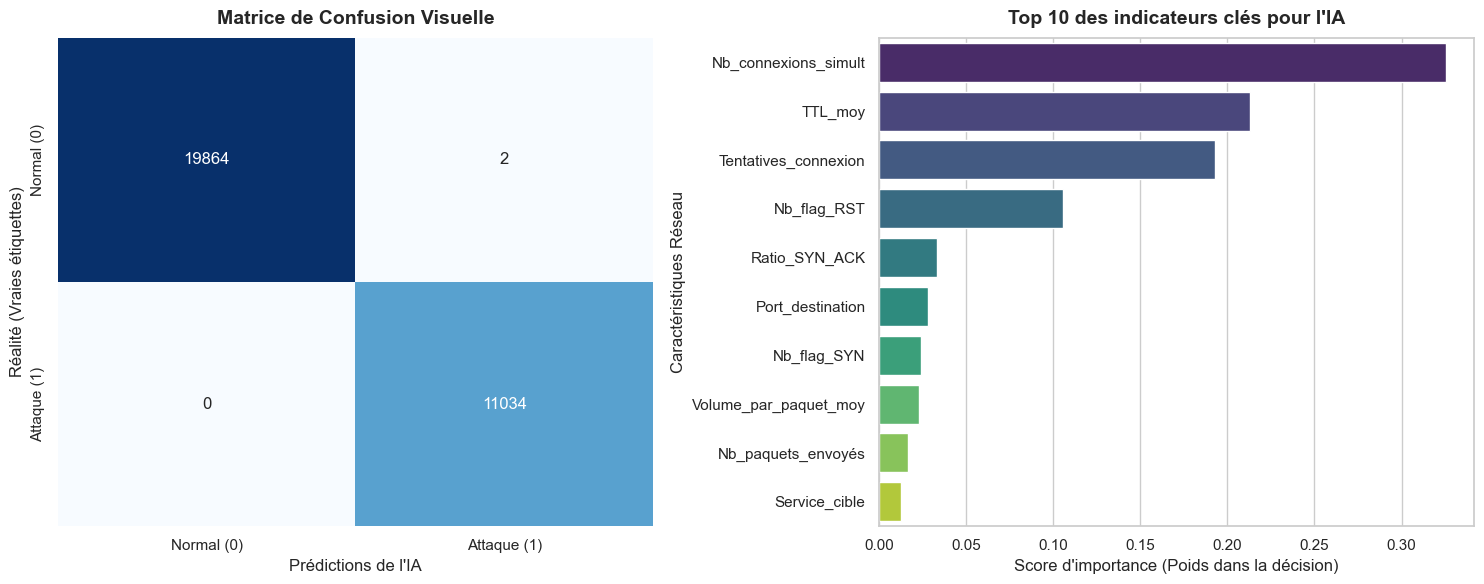

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import warnings

# --- LA MAGIE ICI : On cache tous les avertissements rouges indésirables ---
warnings.filterwarnings("ignore")

# On configure le style des graphiques
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# =====================================================================
# GRAPHique 1 : LA MATRICE DE CONFUSION VISUELLE
# =====================================================================
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Attaque (1)'],
            yticklabels=['Normal (0)', 'Attaque (1)'])

plt.title("Matrice de Confusion Visuelle", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Prédictions de l'IA", fontsize=12)
plt.ylabel("Réalité (Vraies étiquettes)", fontsize=12)

# =====================================================================
# GRAPHique 2 : LES INGRÉDIENTS LES PLUS IMPORTANTS POUR L'IA
# =====================================================================
plt.subplot(1, 2, 2)

importances = modèle_foret.feature_importances_
indices = np.argsort(importances)[::-1]

top_colonnes = X.columns[indices]
top_importances = importances[indices]

# Correction de la syntaxe Seaborn pour éviter l'alerte future
sns.barplot(x=top_importances[:10], y=top_colonnes[:10], hue=top_colonnes[:10], palette="viridis", legend=False)

plt.title("Top 10 des indicateurs clés pour l'IA", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Score d'importance (Poids dans la décision)", fontsize=12)
plt.ylabel("Caractéristiques Réseau", fontsize=12)

# Affichage propre sans fioritures
plt.tight_layout()
plt.show()

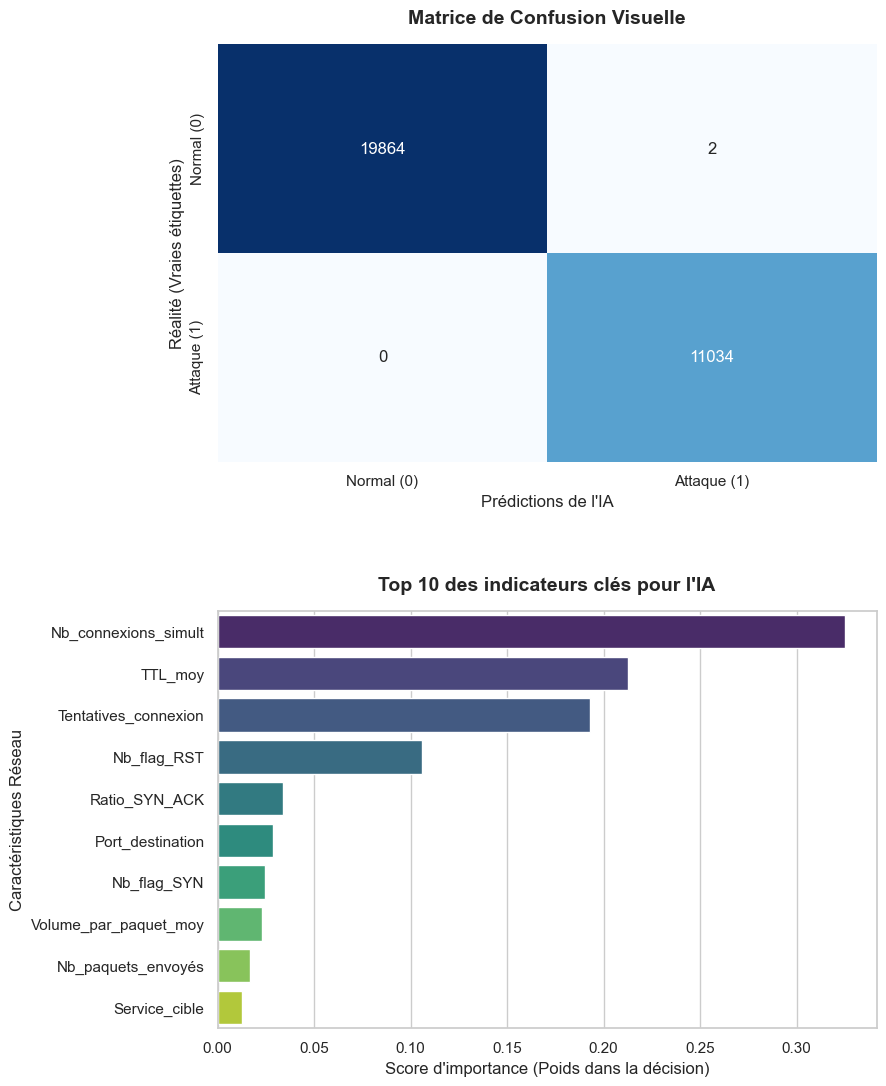